# 01 — Dataset Exploration

Summary statistics, feature distributions, and class balance of the UCI Letter Recognition dataset.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import FEATURE_COLUMNS, LABEL_COLUMN, load_raw
from src.utils import figures_dir, set_seed

set_seed(42)
sns.set_context('notebook')

In [2]:
df = load_raw()
print('Shape:', df.shape)
df.head()

Shape: (20000, 17)


,letter,x-box,y-box,width,high,onpix,x-bar,y-bar,x2bar,y2bar,xybar,x2ybr,xy2br,x-ege,xegvy,y-ege,yedgex
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


count     26.000000
mean     769.230769
std       23.174655
min      734.000000
25%      752.250000
50%      767.000000
75%      786.750000
max      813.000000
Name: count, dtype: float64


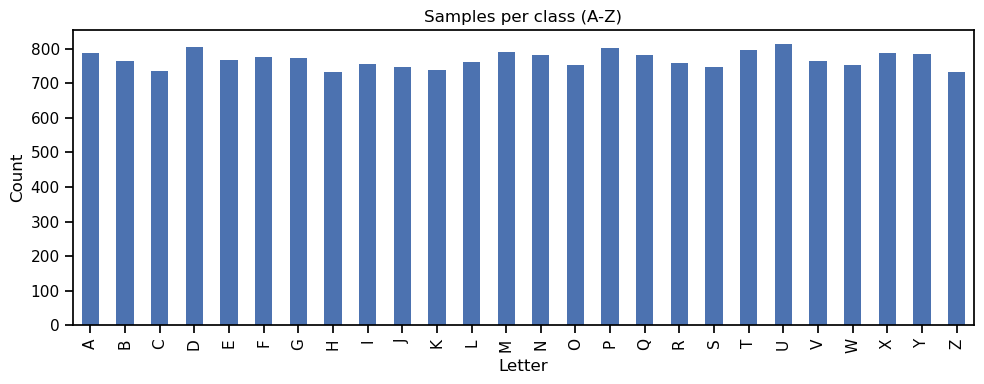

In [3]:
# Class balance across A-Z
counts = df[LABEL_COLUMN].value_counts().sort_index()
print(counts.describe())

fig, ax = plt.subplots(figsize=(10, 4))
counts.plot.bar(ax=ax, color='#4c72b0')
ax.set_title('Samples per class (A-Z)')
ax.set_xlabel('Letter')
ax.set_ylabel('Count')
fig.tight_layout()
fig.savefig(figures_dir() / 'class_balance.png', dpi=200)
plt.show()

In [4]:
# Feature summary statistics
df[FEATURE_COLUMNS].describe().T

,count,mean,std,min,25%,50%,75%,max
x-box,20000.0,4.02355,1.913212,0.0,3.0,4.0,5.0,15.0
y-box,20000.0,7.03550,3.304555,0.0,5.0,7.0,9.0,15.0
width,20000.0,5.12185,2.014573,0.0,4.0,5.0,6.0,15.0
high,20000.0,5.37245,2.261390,0.0,4.0,6.0,7.0,15.0
onpix,20000.0,3.50585,2.190458,0.0,2.0,3.0,5.0,15.0
x-bar,20000.0,6.89760,2.026035,0.0,6.0,7.0,8.0,15.0
y-bar,20000.0,7.50045,2.325354,0.0,6.0,7.0,9.0,15.0
x2bar,20000.0,4.62860,2.699968,0.0,3.0,4.0,6.0,15.0
y2bar,20000.0,5.17865,2.380823,0.0,4.0,5.0,7.0,15.0
xybar,20000.0,8.28205,2.488475,0.0,7.0,8.0,10.0,15.0


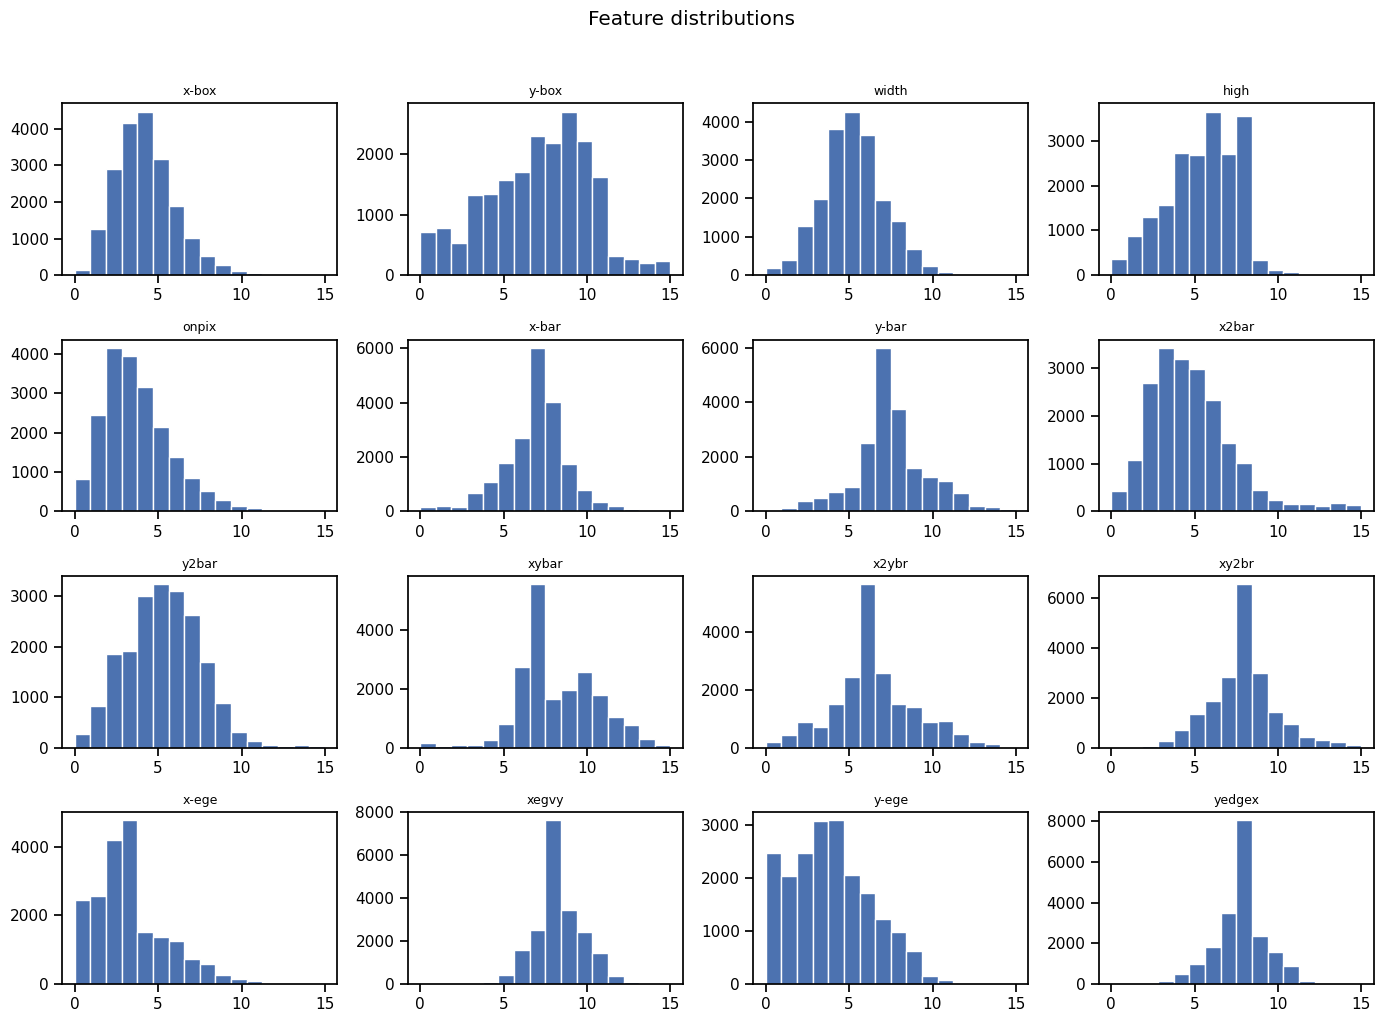

In [5]:
# Feature distributions
fig, axes = plt.subplots(4, 4, figsize=(14, 10))
for col, ax in zip(FEATURE_COLUMNS, axes.ravel()):
    ax.hist(df[col], bins=16, color='#4c72b0', edgecolor='white')
    ax.set_title(col, fontsize=9)
fig.suptitle('Feature distributions', y=1.02)
fig.tight_layout()
fig.savefig(figures_dir() / 'feature_distributions.png', dpi=200, bbox_inches='tight')
plt.show()

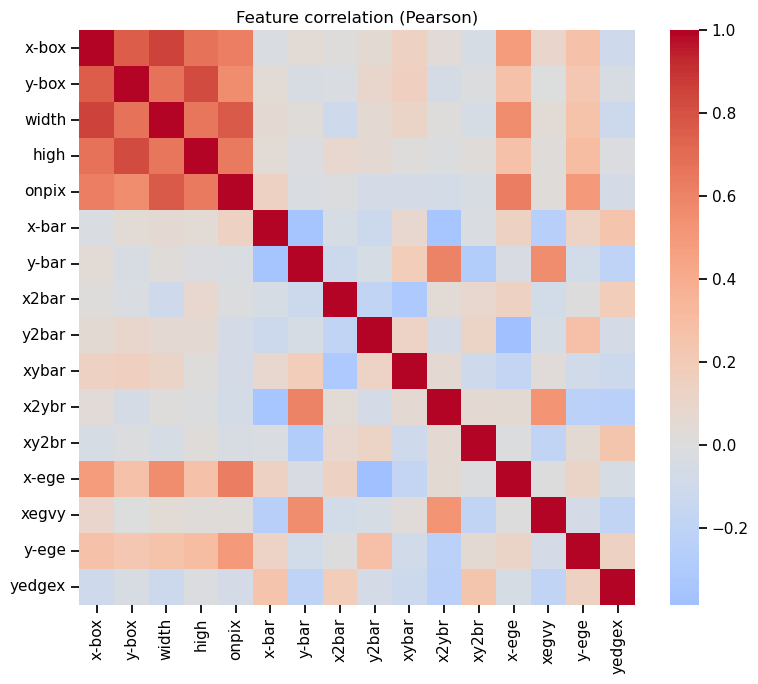

In [6]:
# Feature correlation heatmap
corr = df[FEATURE_COLUMNS].corr()
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Feature correlation (Pearson)')
fig.tight_layout()
fig.savefig(figures_dir() / 'feature_correlation.png', dpi=200)
plt.show()

The dataset is approximately balanced across classes (~734–813 samples per letter), and all 16 features are integers in the range 0–15. Several features show moderate pairwise correlation, motivating the StandardScaler + nonlinear classifier approach used downstream.